In [1]:
# Basically a copy of lsst_eval but make more plots of the basis functions
# 20260527 has moon

import logging

logging.getLogger("lsst_survey_sim").setLevel(logging.INFO)
logging.getLogger("rubin_nights").setLevel(logging.INFO)

# This notebook is in general the same as the "schedview_notebooks/prenight/run_sim.ipynb" notebook
# and will periodically be synced with this other notebook  - thus the references to TimesSquare.

# Will be ignored in Times Square
import rubin_nights.dayobs_utils as rn_dayobs

day_obs = rn_dayobs.day_obs_str_to_int(rn_dayobs.today_day_obs())
day_obs = 20260527
sim_nights = 1

start_after_last_visit = True
start_from_snapshot = False
run_no_downtime = True

# Run simulation for {{ params.day_obs }} for {{ params.sim_nights }} nights.

Run an FBS simulation using model inputs for the observatory and seeing.

Longer simulations should generally not be run in TimesSquare as the notebook will time out. Longer simulations should usually have downtime and weather closures applied, and this notebook will set those flags (`add_downtime`, `add_clouds`) accordingly for use in other locations. For longer simulations starting in the past, the real on-sky availability can be used by also setting `real_downtime`.

Setting `run_no_downtime` will turn off all downtime (weather and maintenance) options and run simulations from -12 to -12 twilight. 

Shorter simulations run in the past usually also want to match the actual on-sky availability, and `real_downtime` will be set for these automatically to accomplish this, unless `run_no_downtime` is set.

Shorter simulations run in the future usually want no downtime, so `add_downtime` and `add_clouds` will be set to False. These simulations will be similar to those run with `run_no_downtime`.

For simulations running for the current day_obs, there are some potentially interesting pathways: 
* start at the start of the night and run the simulation as usual (no downtime, no clouds). The 'start of the night' is defined as - sunset, if sunset has not yet past; now, if no science visits have yet been acquired; the time of the first science visit, if science visits were acquired. Set `run_no_downtime` = False and `start_after_last_visit` = False.
* start after the last currently acquired visit, if science visits have been acquired. Set `start_after_last_visit` = True.

There is another option, to start from a scheduler snapshot from the summit. Set `start_from_snapshot` = True. However, this has a good chance of failing, because TimesSquare does not have the same version of rubin_scheduler as is available at the summit so these can be incompatible. In general, this is only useful for special cases and could be considered an 'advanced' option.


In [2]:
import logging

logging.getLogger("lsst_survey_sim").setLevel(logging.INFO)
logging.getLogger("rubin_nights").setLevel(logging.INFO)

import getpass

# This forces an upgrade of the necessary packages, pip installing into the user's space
if "noteburst" in getpass.getuser():
    print("Running in times square")
    print("Updating lsst_survey_sim and ts_fbs_utils and rubin_nights")
    # Note that a regular user running this in jupyter lab can run these commands to get the packages pip installed as well
    !pip install --user --upgrade git+https://github.com/lsst-sims/rubin_nights.git --no-deps --no-build-isolation > /dev/null 2>&1
    !pip install --user --upgrade git+https://github.com/lsst-sims/lsst_survey_sim.git  --no-deps --no-build-isolation  > /dev/null 2>&1
    !pip install --user --upgrade git+https://github.com/lsst-ts/ts_fbs_utils.git  --no-deps --no-build-isolation > /dev/null 2>&1

In [3]:
import rubin_scheduler
import lsst.ts.fbs.utils
import lsst_survey_sim

# Check/report which versions are available
# Note that you can often run with a newer version of rubin_scheduler
# But then snapshots are quite likely to fail
print("rubin_scheduler", rubin_scheduler.__version__)
print("ts_fbs_utils", lsst.ts.fbs.utils.__version__)
print("lsst_survey_sim", lsst_survey_sim.__version__)

rubin_scheduler 4.0.1
ts_fbs_utils ?
lsst_survey_sim 1.1.1.dev0+gd22e0b8d6.d20260527


In [5]:
import healpy as hp
import numpy as np
from astropy.coordinates import SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u

def healpix_radec_to_altaz(in_hpx_map, nside=512):
    npix = hp.nside2npix(nside)
    hpx_map = hp.ud_grade(in_hpx_map, nside)

    theta_altaz, phi_altaz = hp.pix2ang(nside, np.arange(npix))
    altaz_coords = SkyCoord(
        alt=(0.5*np.pi - theta_altaz) * u.rad,
        az=phi_altaz * u.rad,
        frame=AltAz(
            obstime=Time(conditions.mjd, format='mjd'),
            location=rn_dayobs.rubin_observer().location
        )
    )
    radec = altaz_coords.transform_to("icrs")

    pix = hp.ang2pix(
        nside,
        theta=(0.5*np.pi - radec.dec.to(u.rad).value),
        phi=radec.ra.to(u.rad).value
    )
    altaz_map = hpx_map[pix]

    return altaz_map

In [6]:
# Some configuration content

import getpass
import os
import sys
import yaml

# Who is running the notebook? Some of us have preferences ..
username = getpass.getuser()
# Where is the notebook running? (RSPs are 'special')
current_location = os.getenv("EXTERNAL_INSTANCE_URL", "")

run_generate_ddfs = True # Will be overriden to False if possible

# RUBIN_SIM_DATA_DIR at usdf
if 'usdf' in current_location:
    os.environ["RUBIN_SIM_DATA_DIR"] = "/sdf/data/rubin/shared/rubin_sim_data"
    run_generate_ddfs = False

# TOKEN CONFIGURATION
# Are you on an RSP?
if current_location != "":
    # You are on an rsp.
    # You should use the default RSP values, whether summit/base/USDF.
    tokenfile = None
    site = None
    if 'usdf' in current_location:
        site = "usdf" # only need to set this for edge case of fetching snapshots
    run_generate_ddfs = False

# If you are outside of an RSP? - just use USDF and your own USDF-RSP token
# See https://rsp.lsst.io/guides/auth/creating-user-tokens.html
else:
    # Substitute the location of your own tokenfile
    tokenfile = os.getenv("ACCESS_TOKEN_FILE", "")
    site = os.getenv("DATA_SITE", "")
    if tokenfile == "":
        # A very reasonable backup.
        tokenfile = os.path.join(os.path.expanduser("~"), ".lsst/usdf_rsp")
        site = 'usdf'

# PATH MODIFICATIONS FOR ERIC
# This is a useful technique for anyone to use a non-pip installed version of the software
# Note that `setup -j lsst_survey_sim -r <lsst_survey_sim_directory>` (etc) should also work
if username=='neilsen' and current_location=="https://usdf-rsp.slac.stanford.edu":
    # Modifications of the python path with
    # sys.path do not work if the same namespace
    # is already scanned in the PYTHONPATH.
    # Get rid of the modules pre-loaded so the
    # interpreter reloads lsst.blah.blah.blah
    # after we have made our modifications
    # to sys.path.
    sys.modules.pop("lsst.ts", None)
    sys.modules.pop("lsst", None)
    # - add ts_fbs_utils and lsst_survey_sim to the path
    sys.path.insert(0, "/sdf/data/rubin/user/neilsen/devel/lsst_survey_sim")
    sys.path.insert(0, "/sdf/data/rubin/user/neilsen/devel/ts_fbs_utils/python")


# CONFIGURE PATHS for ts_config_scheduler_root (where the top-level FBS configuration lives)
ts_config_scheduler_root = None

if username=='neilsen' and current_location=="https://usdf-rsp.slac.stanford.edu":
    ts_config_scheduler_root = "/sdf/data/rubin/user/neilsen/devel/ts_config_scheduler"
    do_git_stuff = False
    run_generate_ddfs = False

elif username=='lynnej' and current_location == "":
    ts_config_scheduler_root = "/Users/lynnej/lsst_repos/ts_config_scheduler"
    do_git_stuff = True
    run_generate_ddfs = True

elif username=='yoachim':
    site = 'usdf-dev'

# For everyone who did not set ts_config_scheduler_root path
if ts_config_scheduler_root is None:
    # Just make a new clone for ts_config_scheduler in a temporary directory
    import tempfile
    tmpdir = tempfile.mkdtemp()
    ts_config_scheduler_root = os.path.join(tmpdir, "ts_config_scheduler")
    ts_config_is_temp = True
    do_git_stuff = True
else:
    ts_config_is_temp = False

assert isinstance(ts_config_scheduler_root, str), "Please set ts_config_scheduler_root"

In [7]:
# Import the remaining 
import warnings
import copy

import numpy as np
import pandas as pd
import sqlite3
import healpy as hp
import matplotlib.pyplot as plt
import colorcet as cc
import skyproj
from itertools import cycle
from IPython.display import display, HTML

import datetime
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
import astropy.units as u

from rubin_scheduler.site_models import Almanac
from rubin_scheduler.scheduler import sim_runner
from rubin_scheduler.scheduler.schedulers import CoreScheduler
from rubin_scheduler.scheduler.features import Conditions
from rubin_scheduler.scheduler.utils import TargetoO, SimTargetooServer, SchemaConverter
from rubin_scheduler.utils import ddf_locations, angular_separation, approx_ra_dec2_alt_az, Site, SURVEY_START_MJD

import rubin_sim.maf as maf
from rubin_sim.data import get_baseline

from rubin_nights import connections
import rubin_nights.lfa_data as rn_lfa
import rubin_nights.dayobs_utils as rn_dayobs
import rubin_nights.plot_utils as rn_plots
import rubin_nights.augment_visits as augment_visits
import rubin_nights.rubin_scheduler_addons as rn_sch
import rubin_nights.rubin_sim_addons as rn_sim
import rubin_nights.observatory_status as observatory_status
import rubin_nights.scriptqueue as scriptqueue
import rubin_nights.scriptqueue_formatting as scriptqueue_formatting

from lsst_survey_sim import lsst_support, simulate_lsst, plot

# Will swap to use lsst_utils .. 
band_colors = rn_plots.PlotStyles.band_colors
band_shapes = rn_plots.PlotStyles.band_symbols

#%load_ext memory_profiler

In [8]:
# The default is to run this notebook for one day (today). 
# In this case, you generally want no downtime or clouds - just all the possible visits for tonight all night.
# However -- you COULD run in the past, 
# in which case you might want to run at the times the FBS was on-sky (real_downtime=True).
# You could also run for more than one night, 
# in which case  you might want to run with downtime and clouds (add_downtime=True, add_clouds=True).
# This cell evaluates if you are running for tonight, or in the past and sets the flags according to the logic above.

print(f"Simulation for {sim_nights} nights starting on : {day_obs} (MJD {rn_dayobs.day_obs_to_time(day_obs).mjd:.3f})")

sim_flags = lsst_support.set_sim_flags(day_obs, sim_nights)
day_obs = sim_flags["day_obs"]
end_day_obs = sim_flags["end_day_obs"]
downtime_start_day_obs = sim_flags["downtime_start_day_obs"]
today_day_obs = sim_flags["today_day_obs"]
add_downtime = sim_flags["add_downtime"]
real_downtime = sim_flags["real_downtime"]
add_clouds = sim_flags["add_clouds"]

if run_no_downtime:
    add_downtime = False
    real_downtime = False
    add_clouds = False

print("Setting up to with downtimes like:")
print("add_downtime =", add_downtime)
print("real_downtime = ", real_downtime)
print("add_clouds = ", add_clouds)
print("day_obs = ", day_obs)
print("end_day_obs =", end_day_obs)


# Used for various things inside the FBS including footprints and DDF start
survey_start = SURVEY_START_MJD  

# Programs to consider FBS on-sky time
programs = simulate_lsst.SCIENCE_PROGRAMS
print("Potential science programs : ", programs)

print(" ======= ")

sunset, sunrise = rn_dayobs.day_obs_sunset_sunrise(day_obs, sun_alt=-12)

print(f"DayObs {day_obs}, -12 deg sunset {sunset.iso}, -12 deg sunrise {sunrise.iso}")


if sim_nights < 3:

    sunset18, sunrise18 = rn_dayobs.day_obs_sunset_sunrise(day_obs, sun_alt=-18)
    print(f"DayObs {day_obs}, -18 deg sunset {sunset18.iso}, -18 deg sunrise {sunrise18.iso}")
    
    almanac = Almanac(mjd_start=SURVEY_START_MJD)
    night_events = almanac.get_sunset_info(mjd=sunset.mjd)
    moon_phase = almanac.get_sun_moon_positions(sunset.mjd)['moon_phase']
    if not np.isnan(night_events['moonrise']):
        moonrise = Time(night_events['moonrise'], format='mjd', scale='utc')
    else:
        moonrise = None
    if not np.isnan(night_events['moonset']):
        moonset = Time(night_events['moonset'], format='mjd', scale='utc')
    else:
        moonset = None
    moon_info = f"DayObs {day_obs} moon phase {moon_phase :.1f} (0=new, 100=full);"
    if moonrise is not None:
        moon_info += f", moonrise at {moonrise.utc.iso}"
    if moonset is not None:
        moon_info += f", moonset at {moonset.utc.iso}"
    print(moon_info)

Simulation for 1 nights starting on : 20260527 (MJD 61187.500)
Setting up to with downtimes like:
add_downtime = False
real_downtime =  False
add_clouds =  False
day_obs =  20260527
end_day_obs = 20260528
Potential science programs :  ['BLOCK-407', 'BLOCK-408', 'BLOCK-416', 'BLOCK-417', 'BLOCK-419', 'BLOCK-421']
DayObs 20260527, -12 deg sunset 2026-05-27 22:47:38.838, -12 deg sunrise 2026-05-28 10:34:15.162
DayObs 20260527, -18 deg sunset 2026-05-27 23:16:36.023, -18 deg sunrise 2026-05-28 10:05:16.295
DayObs 20260527 moon phase 79.2 (0=new, 100=full);, moonrise at 2026-05-28 19:58:31.811, moonset at 2026-05-28 08:56:59.622


In [9]:
# Conversion from times square yaml inputs
day_obs = int(day_obs)
sim_nights = int(sim_nights)

#if run_no_downtime:
#    if start_after_last_visit:
#        run_no_downtime = False
#        print("Running without downtime for the full night is logically incompatible with starting after the last visit in the night.")
#        print("Setting run_no_downtime to False.")

if day_obs < rn_dayobs.day_obs_str_to_int(rn_dayobs.today_day_obs()):
    start_after_last_visit = False
    print("Running on a day in the past and starting after the last visit is not supported.")
    print("Setting start_after_last_visit to False")

print("day_obs", day_obs)
print("current day_obs", rn_dayobs.time_to_day_obs_int(Time.now()))
print("run_no_downtime", run_no_downtime)
print("start_after_last_visit", start_after_last_visit)

Running on a day in the past and starting after the last visit is not supported.
Setting start_after_last_visit to False
day_obs 20260527
current day_obs 20260605
run_no_downtime True
start_after_last_visit False


In [10]:
# Connect to endpoints. (please ignore segwarides warnings for now)
endpoints = simulate_lsst.get_endpoints(tokenfile=tokenfile, site=site)

In [11]:
# Fetch summit configuration information, for comparison

# configuration information
q = endpoints['efd'].select_top_n('lsst.sal.Scheduler.logevent_configurationApplied', ["configurations", "salIndex", "private_origin", "url", "version"], 1, time_cut=sunset, index=1)
q2 = endpoints['efd'].select_time_series('lsst.sal.Scheduler.logevent_configurationApplied', ["configurations", "salIndex", "private_origin", "url", "version"], sunset, sunrise, index=1)
q = pd.concat([q, q2])
def strip_repo(x: pd.Series):
    return x.url.split("/")[-3]
def strip_version(x: pd.Series):
    return x.version.replace("heads/", "")
def strip_yaml(x: pd.Series):
    return x.configurations.split(",")[-1]
config_repo = q.apply(strip_repo, axis=1)
config_version = q.apply(strip_version, axis=1)
config_yaml = q.apply(strip_yaml, axis=1)
configs = pd.DataFrame([config_repo, config_version, config_yaml], columns=q.index, index=['config_repo', 'config_commit', 'config_yaml']).T
current_commit = config_version.iloc[0]
display(configs)
print(f"ts_config_scheduler commit {current_commit}")

q = endpoints['efd'].select_top_n("lsst.sal.Scheduler.logevent_dependenciesVersions", ["scheduler", "downtimeModel"], 1, time_cut=sunset, index=1)
q2 = endpoints['efd'].select_time_series("lsst.sal.Scheduler.logevent_dependenciesVersions", ["scheduler", "downtimeModel"], sunset, sunrise, index=1)
q = pd.concat([q, q2])
display(q)
fbs_version = q['downtimeModel'].iloc[-1]
print(f"fbs_version in use {fbs_version}")

,config_repo,config_commit,config_yaml
time,,,
2026-05-25 07:27:33.402196+00:00,ts_config_scheduler,tags/v0.3.3-0-g876584a,fbs_config_lsst_survey.yaml
2026-05-27 23:34:35.040317+00:00,ts_config_scheduler,tags/v0.3.5-0-gbf33d80,fbs_config_lsst_survey.yaml


ts_config_scheduler commit tags/v0.3.3-0-g876584a


,scheduler,downtimeModel
time,,
2026-05-25 07:27:33.399117+00:00,feature_scheduler,3.21.0
2026-05-27 23:34:35.037035+00:00,feature_scheduler,3.21.0


fbs_version in use 3.21.0


In [12]:
# This cell will let you update your version of `ts_config_scheduler` to the commit from the configuration above. (not clear if desirable).
# But it would also just let you clone `ts_config_scheduler` if you didn't have it already. (useful for times square). 
# If `do_git_stuff` is False, none of these git updates will happen anyway. 

if do_git_stuff:
    # Git checkout ts_config_scheduler and set the configs to use.
    if sim_nights > 10:
        ts_commit = 'develop'
    else:
        # For any short simulation, use the current commit so we pick up short-term changes
        ts_commit = current_commit
    simulate_lsst.get_config_repo(ts_commit, clone_path=ts_config_scheduler_root)

# Now find the paths to the actual survey configurations
# All FBS science surveys will look like `fbs_config_lsst_survey..` at the moment

with open(os.path.join(ts_config_scheduler_root, "Scheduler/v9", config_yaml.values[0]), 'r') as file:
    data = yaml.safe_load(file)
summit_config_path = data['maintel']['feature_scheduler_driver_configuration']['scheduler_config']
config_path = summit_config_path.split("ts_config_scheduler")

if "fbs_config_lsst_survey" in config_path:
    config_script_path = os.path.join(ts_config_scheduler_root, config_path)
else:
    # There are other configs that can be in use but we are not likely to be interested in simulating those.
    # Fall back:
    config_script_path = os.path.join(ts_config_scheduler_root, "Scheduler/feature_scheduler/maintel/", "fbs_config_lsst_survey.py")

# Now try to set the DDF config path, if desired.
# This is used to generate the pre-computed DDF observations, if not already present. 
# The value can be safely set to None, if the precomputed observations (a file like `ts_ddf_array_<hash>.npz`)
# appropriate for this configuration exists in `RUBIN_SIM_DATA_DIR`.
# On the RSP, this will be true.
# TimesSquare or other environments without lsst_survey_sim available outside of this conda env (i.e. `setup` or sys.path modification)
# will not be able to pregenerate the file anyway so should always be None.

if run_generate_ddfs:
    # Try to parse config script to find matching ddf generation script
    # Usually this is just done by humans but linting should make this match. 
    config_ddf_script_path = None
    with open(config_script_path, 'r') as file:
        for line in file:
            if "science_program = " in line:
                program = line.strip().replace("science_program = ", "")
                program = program.replace("BLOCK-", "block_")
                program = program.replace('"', '')
                config_ddf_script_path = os.path.join(ts_config_scheduler_root, "Scheduler/ddf_gen", f"lsst_ddf_gen_{program}.py")
else:
    # Use an already pre-computed DDF file
    config_ddf_script_path = None

print(f"Using FBS configuration {config_script_path}")
if config_ddf_script_path is not None:
    print(f"Using FBS DDF configuration script {config_ddf_script_path}")
else:
    print("Will use an assumed-existing precomputed DDF file.")

Using FBS configuration /Users/lynnej/lsst_repos/ts_config_scheduler/Scheduler/feature_scheduler/maintel/fbs_config_lsst_survey.py
Using FBS DDF configuration script /Users/lynnej/lsst_repos/ts_config_scheduler/Scheduler/ddf_gen/lsst_ddf_gen_block_407.py


In [13]:
# Retrieve previous visits to start scheduler.
# Note that we will try to retrieve visits up to day_obs + 1 day. 
# This will allow using the actual on-sky time even for day_obs.
# Includes a step to write to disk and option to read back,
# because re-running this notebook locally can be annoying to wait.

refresh_visits = False

if refresh_visits:
    initial_opsim = simulate_lsst.fetch_previous_visits(end_day_obs, tokenfile=tokenfile, site=site, fetch_with_tap=True)
    if initial_opsim is not None:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always") 
            initial_opsim.to_hdf("opsim.h5", key='visits')
else:
    initial_opsim = pd.read_hdf("opsim.h5")

if initial_opsim is None:
    print("No visits found")
    print("If this was unexpected -- this is probably a good time to abort this sim.")
else:
    print(f"Found {len(initial_opsim)} visits")
    print(f"max day_obs in visits {initial_opsim.day_obs.max()}")
    print(f"will be running simulation for dayobs {day_obs}")

Found 45894 visits
max day_obs in visits 20260526
will be running simulation for dayobs 20260527


In [14]:
# Make a version for summit? (this is a special case probably should be false)
summit_version = False
if summit_version:
    import sqlite3
    
    sc = SchemaConverter()
    # basically this is dropping columns
    o1 = sc.opsimdf2obs(initial_opsim)
    o2 = sc.obs2opsim(o1)
    o2["note"] = o2["scheduler_note"].copy()

    dbfile = f"fbs_{day_obs}.db"
    con = sqlite3.connect(dbfile)
    o2.to_sql("observations", con, index=False, if_exists="replace")
    con.close()

In [15]:
# Retrieve ToO events. 
# Because ToO events are only available at either summit or base (with different information in each!)
# this will not work from the USDF. The `test_too.p` is a pickle of the ToO information from the 
# too running 20251114 - 20251121 and will let the FBS set up accordingly.

import pickle
add_toos = False

if add_toos:
    query_toos = False
    if query_toos:
        lookback = TimeDelta(1, format='jd')
        toos = simulate_lsst.fetch_too_events(sunset - lookback, sunrise, site='summit')
        if toos is not None:
            with open('test_too.p', 'wb') as f:
                pickle.dump(toos, f)
    else:
        try:
            with open('test_too.p', 'rb') as f:
                toos = pickle.load(f)
                # modify -- the pickle has this set to 1 and that is bad.
                toos[0].duration = 10.0
        except FileNotFoundError:
            toos = None
else:
    toos = None


if toos is not None:
    print(f"Retrieved {len(toos)} ToOs")
    # Wrap up ToOs for sim target server 
    too_server = SimTargetooServer(toos)
else:
    print("No ToO information")
    too_server = None

No ToO information


In [16]:
# Configure the band scheduler.
band_scheduler = simulate_lsst.setup_band_scheduler()

# Check what bands it expects for day_obs? 
conditions = Conditions(mjd=sunset.mjd)
print(f"Bands expected to be available {day_obs}", band_scheduler(conditions))

# Check EFD - just a visual check that they match
observatory_status.get_mounted_bandpasses(sunset, sunrise, endpoints['efd'])

Bands expected to be available 20260527 ['g', 'r', 'i', 'z', 'y']


,available_bands
time,
2026-05-27 20:27:59.049750+00:00,"[""g"", ""y"", ""z"", ""i"", ""r""]"


In [48]:
# Configure scheduler.

# Sometimes we might want or need to start from a snapshot (warm start) rather than the configuration (cold start).
if start_from_snapshot:
    # Starting from snapshot won't work if summit scheduler is incompatible with imported rubin_scheduler
    if day_obs < today_day_obs or run_no_downtime:
        t_max_snapshot = day_obs_time
    else:
        t_max_snapshot = Time.now() - TimeDelta(10*60, format='sec')
    starting_scheduler, summit_conditions, nside = simulate_lsst.setup_scheduler_from_snapshot(t_max_snapshot, site)
    assert isinstance(starting_scheduler, CoreScheduler)
    assert isinstance(summit_conditions, Conditions)
    print("summit_conditions time", Time(summit_conditions.mjd, format='mjd').iso)

else:
    # Configure scheduler, pass it ToOs to set up ToOSurveys, and add previous observations.
    if initial_opsim is None:
        print("Just checking - you wanted to run the sim with no previous visits information?")
    with warnings.catch_warnings(record=True) as w:        
        warnings.simplefilter("ignore", category=UserWarning) 
        starting_scheduler, initial_opsim_scheduler_startup, nside = simulate_lsst.setup_scheduler(config_script_path=config_script_path, 
                                                                     config_ddf_script_path=config_ddf_script_path,
                                                                     day_obs=day_obs, 
                                                                     band_scheduler=band_scheduler,
                                                                     too_server=too_server,
                                                                     initial_opsim=initial_opsim)
    # Set summit_conditions to None, because we did not fetch summit conditions.
    summit_conditions = None

In [49]:
# I hacked the survey configuration file to set nside=64 for better plots
nside

64

In [50]:
# Cleanup of the github repo on Times Square.
if ts_config_is_temp:
    import shutil
    shutil.rmtree(tmpdir)

In [51]:
# Now set up the ModelObservatory, including the ToO server and building downtime. 

# To note about the current downtime model:
# Even if add_downtime is False, the end of the night (-18deg twi+) will be blocked as downtime to match observing requirements
# And also the start of the night (-18deg twi-) will be blocked off based on experience getting on sky .. this is improving though! 
# If add_downtime is True:
# The first 100 days from "day_downtime" onward are assigned with a LOT of downtime. Perhaps coming close to our on-sky performance.
# This is based on the downtime model that only exists in lsst_survey_sim.lsst_support.survey_times
# The remainder of the downtime is assigned based on rubin_scheduler.site_models.UnscheduledDowntimeMoreY1Data and decreases through Y1
# Further: if "real_downtime" is True, then the actual on-sky FBS time is used to determine the downtime prior to day_downtime. 

# This is a way to manually swap the seeing.
swap_seeing = False
if swap_seeing:
    # The fill value for missing DIMM values is 1
    seeing=1.5
else:
    seeing=None

    
starting_observatory, survey_info = simulate_lsst.setup_observatory(day_obs=day_obs, 
                                                                    nside=nside, 
                                                                    add_downtime=add_downtime, 
                                                                    add_clouds=add_clouds, 
                                                                    seeing=seeing, 
                                                                    downtime_start_day_obs=downtime_start_day_obs,
                                                                    real_downtime=real_downtime,
                                                                    initial_opsim=initial_opsim, 
                                                                    too_server=too_server,
                                                                    survey_start_mjd=starting_scheduler.survey_start_mjd,
                                                                    tokenfile=tokenfile,
                                                                    site=site)

In [21]:
# Look at time-onsky / availability during the period day_obs to day_obs + mask_days 
# Not necessary but a useful insight into current fraction of downtime to compare with real on-sky time
mask_days = 100
print(f"Modeled availability over next {mask_days} nights")
mask = np.where((survey_info['dayobsmjd'] > rn_dayobs.day_obs_to_time(day_obs).mjd) & (survey_info['dayobsmjd'] < rn_dayobs.day_obs_to_time(day_obs).mjd + mask_days))
print(f"Total nighttime {survey_info["hours_in_night"][mask].sum()}, ")
print(f"total downtime {survey_info["downtime_per_night"][mask].sum()}, ")
print(f"available time {survey_info["hours_in_night"][mask].sum() - survey_info["downtime_per_night"][mask].sum()}")
print(f"Average availability over {mask_days} days {(survey_info["hours_in_night"][mask].sum() - survey_info["downtime_per_night"][mask].sum()) / survey_info["hours_in_night"][mask].sum()}")
print(f"Average availability over survey {survey_info['system_availability']}")

Modeled availability over next 100 nights
Total nighttime 1039.8471172749996, 
total downtime 0.0, 
available time 1039.8471172749996
Average availability over 100 days 1.0
Average availability over survey 1.0


Illustrate survey downtime assumptions


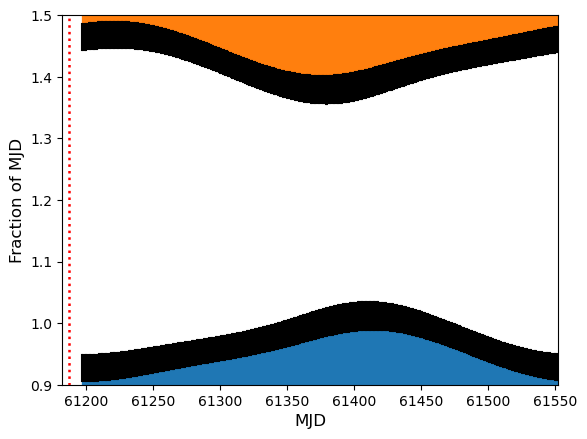

In [22]:
# A plot of the current downtime (black = downtime; orange = -12 deg sunrise, blue = -12 deg sunset
print("Illustrate survey downtime assumptions")
for start, end in survey_info['downtimes']:
    x = np.floor(start - 0.5)
    plt.plot((x, x), (start - x, end - x) , color='k') 
x = np.floor(survey_info['sunsets12'] - 0.5)
y = survey_info['sunsets12'] - x
plt.fill_between(x, 0.8, y)
x = np.floor(survey_info['sunrises12'] - 0.5)
y = survey_info['sunrises12'] - x
plt.axvline(rn_dayobs.day_obs_to_time(day_obs).mjd, color='r', linestyle=':', linewidth=1.8)
plt.fill_between(x, y, 1.6)
plt.ylim(0.9, 1.5)
#plt.xlim(survey_info['survey_start'].mjd, rn_dayobs.day_obs_to_time(day_obs).mjd + 200)
plt.xlim(rn_dayobs.day_obs_to_time(day_obs).mjd - 5, rn_dayobs.day_obs_to_time(day_obs).mjd + 365)
plt.xlabel("MJD", fontsize='large')
_ = plt.ylabel("Fraction of MJD", fontsize='large')
#plt.savefig("onsky_downtime.png", bbox_inches='tight')

Visualize DDF accessibility on 20260527


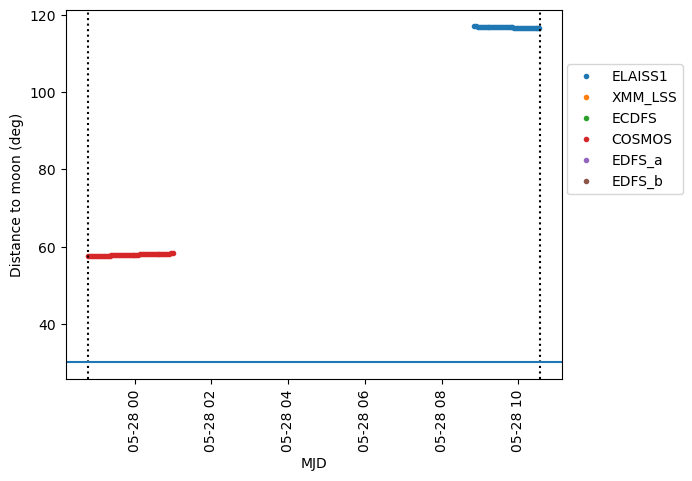

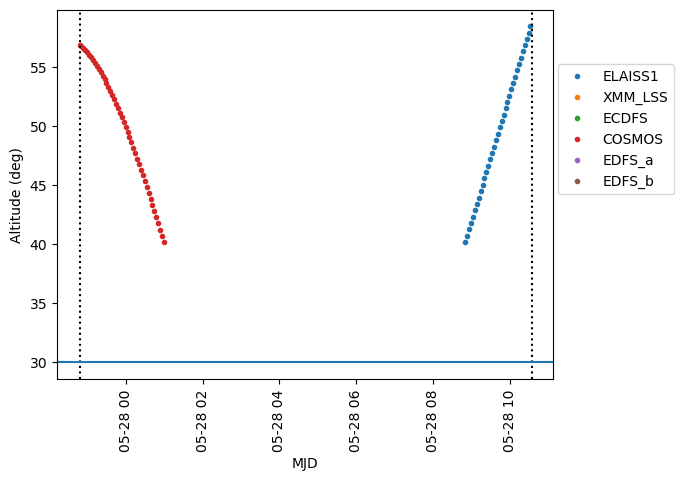

In [23]:
# This can be useful to understsand which DDFs we might or might not be observing, when, and why. 
# Not required for running simulation. 
print(f"Visualize DDF accessibility on {day_obs}")
check_ddfs = True
if check_ddfs:
    ddfs = ddf_locations(skycoords=True)
    lsst_site = Site('LSST')
    times = np.arange(sunset.mjd - 0.1, sunrise.mjd + 0.1, 0.05/24)
    sunmoon = survey_info['almanac'].get_sun_moon_positions(times)
    moon_ra = sunmoon['moon_RA']
    moon_dec = sunmoon['moon_dec']
    sun_alt = np.degrees(sunmoon['sun_alt'])
    ddf_moon_dist = {}
    ddf_alt = {}
    for ddf in ddfs:
        ddf_moon_dist[ddf] = angular_separation(ddfs[ddf].ra.deg, ddfs[ddf].dec.deg, np.degrees(moon_ra), np.degrees(moon_dec))
        alt, az = approx_ra_dec2_alt_az(ddfs[ddf].ra.deg, ddfs[ddf].dec.deg, lsst_site.latitude, lsst_site.longitude, times, lmst=None)
        ddf_alt[ddf] = alt
    
    plt.figure()
    for ddf in ddfs:
        mask = np.where((sun_alt <= -12) & (ddf_alt[ddf] > 40))
        plt.plot(Time(times[mask], format='mjd').to_datetime(), ddf_moon_dist[ddf][mask], marker='.', linestyle='', label=ddf)
    plt.legend(loc=(1.01, 0.5))
    plt.axvline(sunset.to_datetime(), color='k', linestyle=':')
    plt.axvline(sunrise.to_datetime(), color='k', linestyle=':')
    plt.axhline(30)
    plt.xticks(rotation=90)
    plt.xlabel("MJD")
    plt.ylabel("Distance to moon (deg)")
    
    plt.figure()
    for ddf in ddfs:
        mask = np.where((sun_alt <= -12) & (ddf_alt[ddf] > 40))
        plt.plot(Time(times[mask], format='mjd').to_datetime(), ddf_alt[ddf][mask], marker='.', linestyle='', label=ddf)
    plt.legend(loc=(1.01, 0.5))
    plt.axvline(sunset.to_datetime(), color='k', linestyle=':')
    plt.axvline(sunrise.to_datetime(), color='k', linestyle=':')
    plt.axhline(30)
    plt.xticks(rotation=90)
    plt.xlabel("MJD")
    plt.ylabel("Altitude (deg)")

In [52]:
# Use a copy of the model observatory and scheduler below. 
# Rerun this cell if you wish to rerun simulations below. 

observatory = copy.deepcopy(starting_observatory)
scheduler = copy.deepcopy(starting_scheduler)

In [53]:
#slew_scatter = lsst_support.SlewScatter()
slew_scatter = None

In [54]:
# Run the simulation for some nights, from day_obs to day_obs + sim_nights.
print("==================")
print("Running simulation")
print("==================")
sim_duration = sim_nights

observatory, scheduler, observations = sim_runner(
    observatory,
    scheduler,
    band_scheduler=band_scheduler,
    sim_start_mjd=sunset.mjd,
    sim_duration=sim_duration,
    record_rewards=False,
    verbose=True,
    anomalous_overhead_func=slew_scatter,
    n_visit_limit=10
)

Running simulation
Skipped 0 observations
Flushed 0 observations from queue for being stale
Completed 10 observations
ran in 0 min = 0.0 hours


In [55]:
def hp_laea(hp_array, alpha=None, label=None, vmin=None, vmax=None):
    hp.azeqview(hp_array, alpha=alpha, rot=(0, -90, 0), lamb=True, reso=17.5, min=vmin, max=vmax, title=label)
    hp.graticule()

def hp_moll(hp_array, alpha=None, label=None, vmin=None, vmax=None, rot=(0, 0, 0)):
    hp.mollview(hp_array, alpha=alpha, rot=rot, min=vmin, max=vmax, title=label)
    hp.graticule()

In [56]:
#observatory.mjd = (sunset + TimeDelta(5/60/24, format='jd')).utc.mjd
conditions = observatory.return_conditions()
sched = copy.deepcopy(starting_scheduler)
sched.update_conditions(conditions)

lmst = Time(conditions.mjd, format='mjd', location=rn_dayobs.rubin_observer().location).sidereal_time("mean").deg
print("conditions LMST", lmst)
rot = (lmst, conditions.site.latitude, 0)
#rot = (lmst, 0, 0)

conditions LMST 158.24460937791417


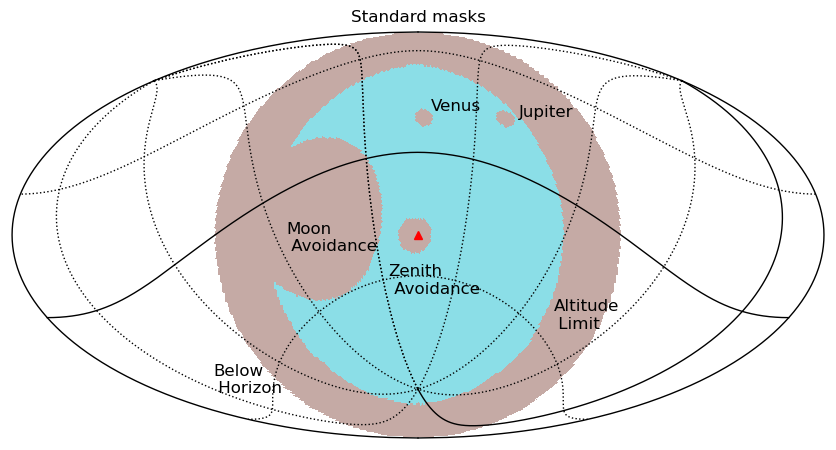

In [57]:
# create safety mask illustration
s = sched.survey_lists[1][0]
safety_masks = s.basis_functions[0:4]

masks = np.zeros(hp.nside2npix(sched.nside))
for bf in safety_masks:
    masks += bf(conditions)
masks[np.isnan(masks)] = 0

horizon = np.where(conditions.alt < 0, np.nan, 0)

hp.mollview(masks  + horizon, alpha=np.ones(len(masks)) * 0.5, rot=rot, min=-1, max=1, cmap='tab10', title="Standard masks", cbar=False, badcolor='white')
hp.projplot(lmst, rn_dayobs.rubin_observer().latitude.deg, '^', markersize=6, color='red', lonlat=True)
hp.projtext(lmst+65, rn_dayobs.rubin_observer().latitude.deg + 10, "Moon\n Avoidance", fontsize='large', lonlat=True)
hp.projtext(lmst+20, rn_dayobs.rubin_observer().latitude.deg - 20, "Zenith\n Avoidance", lonlat=True, fontsize='large')
hp.projtext(np.degrees(conditions.planet_positions['jupiter_RA']) - 5, np.degrees(conditions.planet_positions['jupiter_dec']) + 3, "Jupiter", lonlat=True, fontsize='large')
hp.projtext(np.degrees(conditions.planet_positions['venus_RA']) - 3, np.degrees(conditions.planet_positions['venus_dec']) + 3, "Venus", lonlat=True, fontsize='large')
hp.projtext(lmst-91, rn_dayobs.rubin_observer().latitude.deg - 10, "Altitude\n Limit", fontsize='large', lonlat=True)
#hp.projtext(lmst-120, rn_dayobs.rubin_observer().latitude.deg - 4, "Below\n Horizon", fontsize='large', lonlat=True)
hp.projtext(lmst+160, rn_dayobs.rubin_observer().latitude.deg - 4, "Below\n Horizon", fontsize='large', lonlat=True)
hp.graticule(dpar=45)
#plt.savefig("standard_masks.pdf")

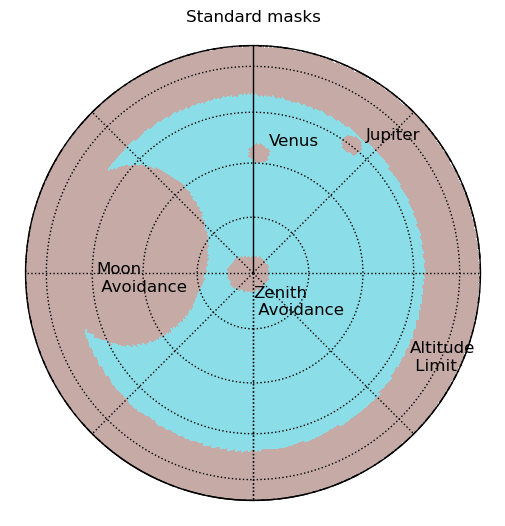

In [129]:
# create safety mask illustration
rot=(180, 90, 0)

s = sched.survey_lists[1][0]
safety_masks = s.basis_functions[0:4]

masks = np.zeros(hp.nside2npix(sched.nside))
for bf in safety_masks:
    masks += bf(conditions)
masks[np.isnan(masks)] = 0

horizon = np.where(conditions.alt < 0, np.nan, 0)

mzmap = healpix_radec_to_altaz(masks  + horizon)



hp.azeqview(mzmap, alpha=np.ones(len(mzmap)) * 0.5, rot=rot, min=-1, max=1, cmap='tab10',
            title="Standard masks", cbar=False, badcolor='white', half_sky=True, lamb=True, flip="geo",
            reso=13/2, xsize=800*2, ysize=800*2)

#hp.projplot(0, 90, '^', markersize=8, color='red', lonlat=True)
alt, az = approx_ra_dec2_alt_az(lmst+65, rn_dayobs.rubin_observer().latitude.deg + 10, conditions.site.latitude, conditions.site.longitude, conditions.mjd)
hp.projtext(az, alt, "Moon\n Avoidance", fontsize='large', lonlat=True)

alt, az = approx_ra_dec2_alt_az(lmst+0, rn_dayobs.rubin_observer().latitude.deg - 15, conditions.site.latitude, conditions.site.longitude, conditions.mjd)
hp.projtext(az, alt, "Zenith\n Avoidance", lonlat=True, fontsize='large')

alt, az = approx_ra_dec2_alt_az(np.degrees(conditions.planet_positions['jupiter_RA']) - 5, np.degrees(conditions.planet_positions['jupiter_dec']) + 3, conditions.site.latitude, conditions.site.longitude, conditions.mjd)
hp.projtext(az, alt, "Jupiter", lonlat=True, fontsize='large')

alt, az = approx_ra_dec2_alt_az(np.degrees(conditions.planet_positions['venus_RA']) - 3, np.degrees(conditions.planet_positions['venus_dec']) + 3, conditions.site.latitude, conditions.site.longitude, conditions.mjd)

hp.projtext(az, alt, "Venus", lonlat=True, fontsize='large')

hp.projtext(lmst+80, rn_dayobs.rubin_observer().latitude.deg + 50, "Altitude\n Limit", fontsize='large', lonlat=True)
#hp.projtext(lmst-120, rn_dayobs.rubin_observer().latitude.deg - 4, "Below\n Horizon", fontsize='large', lonlat=True)
alt, az = approx_ra_dec2_alt_az(lmst+160, rn_dayobs.rubin_observer().latitude.deg - 4, conditions.site.latitude, conditions.site.longitude, conditions.mjd)
hp.projtext(az, alt, "Below\n Horizon", fontsize='large', lonlat=True)
hp.graticule(dpar=20, dmer=45)

# Add a circle patch
ax = plt.gca()
circle = Circle((0.5, 0.5), radius=0.468, transform=ax.transAxes, 
                fill=False, edgecolor='black', linewidth=1)
ax.add_patch(circle)

plt.savefig("standard_masks.pdf")

In [130]:
# Make "big three" illustration
s = copy.deepcopy(sched.survey_lists[5][3])
print(s)
[bf.label() for bf in s.basis_functions]
conditions.current_band = 'r'

#conditions.__dict__
#s.basis_functions

<BlobSurvey survey_name='pair_33, ri' at 0x4227ede80>


In [142]:
conditions.tel_az, conditions.tel_alt,  conditions.tel_ra, conditions.tel_dec

(array([6.08952606]),
 array([0.85963104]),
 ObservationArray([2.63136895]),
 ObservationArray([0.17258712]))

M5Diff r @17754530480
Footprint r @17754529424
Slewtime r @16581255536


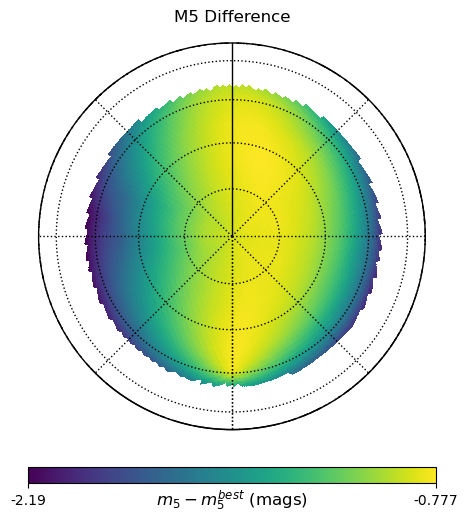

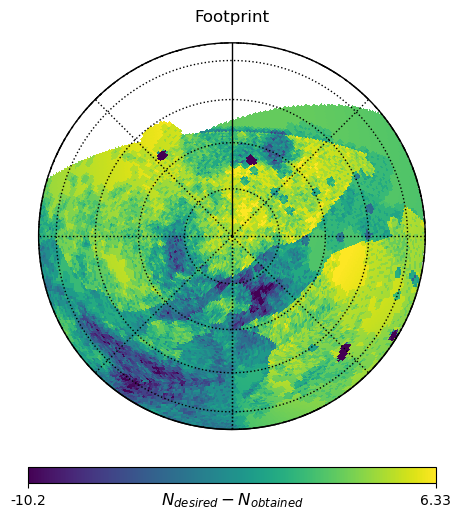

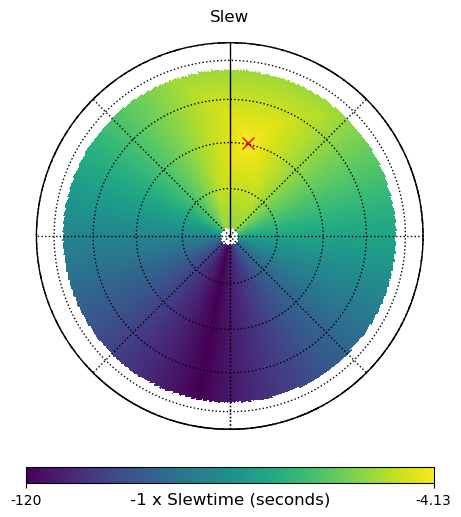

In [156]:

rot=(180, 90, 0)

horizon = np.where(conditions.alt < 0, np.nan, 0)
alpha = np.ones(conditions.alt.size)+2
alpha[np.where(conditions.alt < 0)] = 0


i = 0
bf = s.basis_functions[i]
print(bf.label())
vals = bf(conditions)  #* s.basis_weights[i]
#vals[np.isnan(vals)] = np.nanmean(vals) - abs(np.nanpercentile(vals, 2))
horizon = vals * 0
horizon[np.where(conditions.alt < 0)] = np.nan

alpha[np.isfinite(vals)] = 10

mzmap = healpix_radec_to_altaz(vals + horizon)

alpha = healpix_radec_to_altaz(alpha)

hp.azeqview(mzmap, rot=rot, cmap='viridis', title="M5 Difference", cbar=True, badcolor='none',
           unit=r"$m_5 - m_5^{best}$ (mags)", half_sky=True, lamb=True, flip="geo",
            reso=13/2, xsize=800*2, ysize=800*2)
#hp.projplot(0, 90, '^', markersize=6, color='red', lonlat=True)
hp.projtext(lmst-95, rn_dayobs.rubin_observer().latitude.deg - 10, "Altitude\n Limit", fontsize='large', lonlat=True)
#hp.projtext(lmst-120, rn_dayobs.rubin_observer().latitude.deg - 4, "Below\n Horizon", fontsize='large', lonlat=True)
#hp.projtext(lmst+160, rn_dayobs.rubin_observer().latitude.deg - 4, "Below\n Horizon", fontsize='large', lonlat=True)
hp.graticule(dpar=20, dmer=45)

# Add a circle patch
ax = plt.gca()
circle = Circle((0.5, 0.5), radius=0.468, transform=ax.transAxes, 
                fill=False, edgecolor='black', linewidth=1)
ax.add_patch(circle)

plt.savefig("m5diff.pdf", bbox_inches="tight")

i = 2
bf = s.basis_functions[i] 
print(bf.label())
vals = bf(conditions) #* s.basis_weights[i]
#vals[np.isnan(vals)] = np.nanmean(vals) - abs(np.nanpercentile(vals, 2))
horizon = vals * 0
horizon[(np.where(conditions.alt < 0))] = np.nan
vals = vals + horizon

alpha = np.ones(conditions.alt.size) + 2
alpha[np.where(conditions.alt < 0)] = 0
alpha[np.isfinite(vals)] = 10


mzmap = healpix_radec_to_altaz(vals)
alpha = healpix_radec_to_altaz(alpha)


hp.azeqview(mzmap,  rot=rot, cmap='viridis', min=np.nanpercentile(vals, 0.5), max=np.nanpercentile(vals, 99.5),
            title="Footprint", cbar=True, badcolor='none',
           unit=r"$N_{desired} - N_{obtained}$", half_sky=True, lamb=True, flip="geo",
            reso=13/2, xsize=800*2, ysize=800*2)
#hp.projplot(0, 90, '^', markersize=6, color='red', lonlat=True)

hp.graticule(dpar=20, dmer=45)

# Add a circle patch
ax = plt.gca()
circle = Circle((0.5, 0.5), radius=0.468, transform=ax.transAxes, 
                fill=False, edgecolor='black', linewidth=1)
ax.add_patch(circle)

plt.savefig("footprint.pdf", bbox_inches="tight")

i = 4
bf = s.basis_functions[i] 
print(bf.label())
vals = bf(conditions) * bf.maxtime #* s.basis_weights[i]
#vals[np.isnan(vals)] = np.nanmean(vals) #- abs(np.nanpercentile(vals, 2))
horizon = vals * 0
horizon[(np.where(conditions.alt < 0))] = np.nan
vals = vals + horizon

alpha = np.ones(conditions.alt.size) + 2
alpha[np.where(conditions.alt < 0)] = 0
alpha[np.isfinite(vals)] = 10

mzmap = healpix_radec_to_altaz(vals)
alpha = healpix_radec_to_altaz(alpha)


hp.azeqview(mzmap, rot=rot, cmap='viridis', title="Slew", cbar=True, badcolor='none',
           unit="-1 x Slewtime (seconds)",  half_sky=True, lamb=True, flip="geo",
            reso=13/2, xsize=800*2, ysize=800*2)
#hp.projplot(0, 90, '^', markersize=6, color='red', lonlat=True)


hp.projplot(np.degrees(conditions.tel_az), np.degrees(conditions.tel_alt), 'x', markersize=8, color='red', lonlat=True)
hp.graticule(dpar=20, dmer=45)

# Add a circle patch
ax = plt.gca()
circle = Circle((0.5, 0.5), radius=0.468, transform=ax.transAxes, 
                fill=False, edgecolor='black', linewidth=1)
ax.add_patch(circle)
plt.savefig("slew.pdf", bbox_inches="tight")

pair_33, ri chose 82 visits


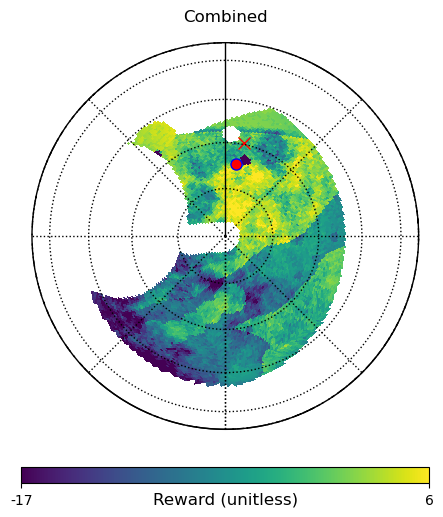

In [159]:
# Make a combo plot
s = copy.deepcopy(sched.survey_lists[5][3])

horizon = np.where(conditions.alt < 0, np.nan, 0)

footprintbf = [(bf, bw) for bf, bw in zip(s.basis_functions, s.basis_weights) if 'Footprint' in bf.label() or "M5" in bf.label()]  

maskbf = [bf for bf in s.basis_functions if 'Avoid' in bf.label() or 'Shadow' in bf.label() or "HaMask" in bf.label()]
mask = np.zeros(hp.nside2npix(nside))
for mbf in maskbf:
    mask += mbf(conditions)

alpha = np.where(np.isnan(mask), 0.3, 1)
alpha = np.where(np.isnan(horizon), 0, alpha)

fp = np.zeros(hp.nside2npix(nside))
for fbf in footprintbf:
    fp += fbf[0](conditions) * fbf[1]

# add slewtime
fp += s.basis_functions[-1](conditions) * s.basis_weights[-1]

fp[np.isnan(fp)] = np.nanmean(fp) - abs(np.nanpercentile(fp, 2))

horizon = np.where(conditions.alt < 0, np.nan, 0)
fp =  fp + horizon


# Remove the time to scheduled and not twilight basis  functions and weights .. 
new_basis_functions = [bf for bf in s.basis_functions if not bf.label().startswith("TimeToScheduled") and not bf.label().startswith("NotTwilight")]
new_basis_weights = [w for w in s.basis_weights if not bf.label().startswith("TimeToScheduled") and not bf.label().startswith("NotTwilight")]
reward = np.zeros(hp.nside2npix(sched.nside))
for bf, bw in zip(new_basis_functions, new_basis_weights):
    reward += bf(conditions) * bw
alpha = np.where(np.isnan(reward), 0.3, 1)
alpha = np.where(np.isnan(horizon), 0, alpha)


mzmap = healpix_radec_to_altaz(reward)

alpha = healpix_radec_to_altaz(alpha)

hp.azeqview(mzmap, rot=rot, min=int(np.nanpercentile(reward, 2)), max=int(np.nanpercentile(reward, 99)),
            badcolor='none', title="Combined", unit="Reward (unitless)",  half_sky=True, lamb=True, flip="geo",
            reso=13/2, xsize=800*2, ysize=800*2)

hp.projplot(np.degrees(conditions.tel_az), np.degrees(conditions.tel_alt), 'x', markersize=8, color='red', lonlat=True)
hp.graticule(dpar=20, dmer=45)

# Add a circle patch
ax = plt.gca()
circle = Circle((0.5, 0.5), radius=0.468, transform=ax.transAxes, 
                fill=False, edgecolor='black', linewidth=1)
ax.add_patch(circle)


# Remove the time to scheduled and not twilight basis  functions and weights .. 
# for i, bf in enumerate(s.basis_functions):
#     print(i, bf.label(), bf(conditions))

keep = np.arange(0, len(s.basis_functions))
keep = keep[np.where((keep != 10) & (keep != 12))] 
new_basis_functions = [s.basis_functions[i] for i in keep]
s.basis_functions = new_basis_functions
new_basis_weights = [s.basis_weights[i] for i in keep]
s.basis_weights = new_basis_weights

obs = s.generate_observations(conditions)
ra = np.degrees(obs['RA'])
dec = np.degrees(obs['dec'])

alt, az = approx_ra_dec2_alt_az(ra, dec, conditions.site.latitude, conditions.site.longitude, conditions.mjd)

#hp.projplot(ra, dec, 'r.', linestyle='-', alpha=0.5, lonlat=True)
print(f'{s.survey_name} chose {len(ra)} visits')
if len(ra)  > 0:
    hp.projplot(az[0], alt[0], 'bo', markersize=8, lonlat=True)
    hp.projplot(az[0], alt[0], 'ro', lonlat=True)
plt.savefig("survey_choice.pdf", bbox_inches="tight")